# Análisis de la producción de hielo de una planta que posee dos compresores

## Descripción del proyecto

Este proyecto analiza los registros de producción de hielo de una empresa entre los años 2023 y 2026.

La producción se realiza principalmente mediante dos compresores. El compresor 2 trabaja con una rolitera (rolitera 1), mientras que el compresor 4 puede trabajar con dos roliteras en simultáneo (rolitera 1 y rolitera 2), permitiendo una mayor capacidad de producción.

El objetivo es analizar la eficiencia de ambos compresores según las horas de funcionamiento y los kilos producidos, y detectar posibles inconsistencias en los registros de producción.

## Preguntas de análisis

1. ¿Cuál de los dos compresores presenta mayor eficiencia productiva, considerando los kilos producidos por hora de funcionamiento?

2. ¿Resulta más eficiente producir durante 24 horas con el compresor 2 y rolitera 1, o durante 12 horas con el compresor 4 utilizando las roliteras 1 y 2?

3. ¿Existen inconsistencias o valores atípicos en los registros de producción y en los relojes de funcionamiento que puedan generar desvíos en la información?

## Fuente de datos

Los datos provienen de registros internos de producción de una fabrica de hielo y se encuentran almacenados en un archivo Excel.

## Herramientas utilizadas

- Google Colab
- Python
- pandas
- matplotlib
- seaborn
- Power BI

## Carga del Dataset y revisión de su estructura con Pandas.

In [69]:
# Importación de librerias que se utilizaran para realizar la limpieza y analisis de los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
# Carga del dataset desde mi Drive
df = pd.read_excel(
    "/content/drive/MyDrive/proyecto final Análisis de datos - UTNBA/informe producción hielo.xlsx",
    sheet_name="produccion"
)

##Rutina para conocer el Dataset

In [72]:
df.head()

,Dia,Mes,Año,Fecha,Usuario,Tipo de Transacción,Número Documento,Compresor,Rolitera,Hora Encendido Compresor,Hora Apago Compresor,Horas Funcionamiento,Descripcion,Cantidad
0,4,1,2023,2023-01-04,rmanera,Alta Producción de Hielo,9,C02 - Compresor 2 - 127,R01 - Rolitera 1,31640.09,31643.05,2.96,ROLITO EN BOLSAS 14 KG,46
1,4,1,2023,2023-01-04,rmanera,Alta Producción de Hielo,10,C02 - Compresor 2 - 127,R01 - Rolitera 1,31643.50,31646.78,3.28,ROLITO EN BOLSAS 14 KG,48
2,5,1,2023,2023-01-05,rmanera,Alta Producción de Hielo,11,C02 - Compresor 2 - 127,R01 - Rolitera 1,31646.78,31649.99,3.21,ROLITO EN BOLSAS 2 KG,276
3,5,1,2023,2023-01-05,rmanera,Alta Producción de Hielo,12,C04 - Compresor 4 - 127,R01 - Rolitera 1,1294.85,1299.26,4.41,ROLITO EN BOLSAS 14 KG,63
4,5,1,2023,2023-01-05,rmanera,Alta Producción de Hielo,13,C02 - Compresor 2 - 127,R01 - Rolitera 1,31649.99,31653.80,3.81,ROLITO EN BOLSAS 2 KG,320


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4293 entries, 0 to 4292
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Dia                       4293 non-null   int64         
 1   Mes                       4293 non-null   int64         
 2   Año                       4293 non-null   int64         
 3   Fecha                     4293 non-null   datetime64[ns]
 4   Usuario                   4293 non-null   object        
 5   Tipo de Transacción       4293 non-null   object        
 6   Número Documento          4293 non-null   int64         
 7   Compresor                 4293 non-null   object        
 8   Rolitera                  4293 non-null   object        
 9   Hora Encendido Compresor  4293 non-null   float64       
 10  Hora Apago Compresor      4293 non-null   float64       
 11  Horas Funcionamiento      4293 non-null   float64       
 12  Descripcion         

In [74]:
df.shape

(4293, 14)

In [75]:
df.columns

Index(['Dia', 'Mes', 'Año', 'Fecha', 'Usuario', 'Tipo de Transacción',
       'Número Documento', 'Compresor', 'Rolitera', 'Hora Encendido Compresor',
       'Hora Apago Compresor', 'Horas Funcionamiento', 'Descripcion',
       'Cantidad'],
      dtype='object')

In [76]:
df.describe()

,Dia,Mes,Año,Fecha,Número Documento,Hora Encendido Compresor,Hora Apago Compresor,Horas Funcionamiento,Cantidad
count,4293.000000,4293.000000,4293.000000,4293,4293.000000,4.293000e+03,4.293000e+03,4.293000e+03,4293.000000
mean,15.626369,6.009317,2024.205684,2024-08-29 22:58:16.855346176,1167.016073,2.148927e+04,2.898765e+04,7.498380e+03,212.361519
min,1.000000,1.000000,2023.000000,2023-01-04 00:00:00,9.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,8.000000,3.000000,2023.000000,2023-10-13 00:00:00,600.000000,1.831510e+03,1.850520e+03,1.710000e+00,32.000000
50%,15.000000,5.000000,2024.000000,2024-09-02 00:00:00,1164.000000,5.399130e+03,5.438980e+03,4.210000e+00,85.000000
75%,23.000000,10.000000,2025.000000,2025-08-12 00:00:00,1748.000000,3.348778e+04,3.351586e+04,9.750000e+00,321.000000
max,31.000000,12.000000,2026.000000,2026-07-31 00:00:00,2301.000000,3.637312e+06,3.695581e+06,3.658989e+06,8356.000000
std,8.724646,3.771664,1.057898,NaN,660.758281,1.466930e+05,2.153092e+05,1.570196e+05,284.908586


### En el análisis descriptivo se observan valores atipicos que se alejan considerablemente de los valores centrales del dataset. Los mismos tienen que ver con las cantidades y las horas de funcionamiento de los compresores. Deberan ser analizados para determinar si son valores reales o posibles errores.

## Preparación y limpieza de los datos

###Valores nulos

In [77]:
df.isnull().sum()

,0
Dia,0
Mes,0
Año,0
Fecha,0
Usuario,0
Tipo de Transacción,0
Número Documento,0
Compresor,0
Rolitera,0
Hora Encendido Compresor,0


#### Observación sobre valores nulos

No se detectaron valores nulos. Sin embargo, el sistema de origen completa algunos campos sin información con el valor 0.

Por este motivo, los valores iguales a 0 deberán analizarse según la variable y el contexto operativo antes de considerarlos datos válidos o faltantes.

In [78]:
columnas_relojes = [
    "Hora Encendido Compresor",
    "Hora Apago Compresor",
    "Horas Funcionamiento"
]

for columna in columnas_relojes:
    print(f"{columna}: {(df[columna] == 0).sum()} valores en 0")

Hora Encendido Compresor: 899 valores en 0
Hora Apago Compresor: 899 valores en 0
Horas Funcionamiento: 902 valores en 0


In [79]:
ceros_reloj = df[
    (df["Hora Encendido Compresor"] == 0) |
    (df["Hora Apago Compresor"] == 0)
]

pd.crosstab(
    ceros_reloj["Compresor"],
    ceros_reloj["Rolitera"]
)

Rolitera,R01 - Rolitera 1,R02 - Rolitera 2
Compresor,,
C02 - Compresor 2 - 127,4,4
C04 - Compresor 4 - 127,17,874


#### Análisis de los registros con valor 0

Se detectaron 899 registros con valor 0 en los relojes de encendido y apagado.

Al analizar estos registros según compresor y rolitera, se observa que 874 corresponden al Compresor 4 trabajando con la Rolitera 2.

Esto coincide con el funcionamiento operativo de la planta: cuando el Compresor 4 trabaja con las dos roliteras simultáneamente, el sistema registra los horarios en la Rolitera 1 y no permite repetirlos en la Rolitera 2.

Por lo tanto, estos valores 0 no serán considerados automáticamente como errores, sino que deberán relacionarse con el registro correspondiente de la Rolitera 1.

Los restantes registros con valor 0 serán analizados individualmente para determinar si corresponden a errores o situaciones reales de producción.

#### Revisión de registros con reloj en 0 fuera del caso habitual

In [80]:
casos_revisar = ceros_reloj[
    ~(
        (ceros_reloj["Compresor"] == "C04 - Compresor 4 - 127") &
        (ceros_reloj["Rolitera"] == "R02 - Rolitera 2")
    )
]

casos_revisar[[
    "Fecha",
    "Número Documento",
    "Compresor",
    "Rolitera",
    "Hora Encendido Compresor",
    "Hora Apago Compresor",
    "Horas Funcionamiento",
    "Descripcion",
    "Cantidad"
]]

,Fecha,Número Documento,Compresor,Rolitera,Hora Encendido Compresor,Hora Apago Compresor,Horas Funcionamiento,Descripcion,Cantidad
117,2023-01-25,82,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 14 KG,12
118,2023-01-25,82,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 2 KG,1038
676,2023-05-19,380,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 4 KG,34
769,2023-07-04,432,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 14 KG,72
1108,2023-10-19,621,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 7 KG,1
1109,2023-10-17,622,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 4 KG,1
2129,2024-08-26,1157,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 14 KG,13
2130,2024-08-26,1157,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 2 KG,341
2363,2024-11-13,1283,C02 - Compresor 2 - 127,R02 - Rolitera 2,0.0,0.0,0.0,ROLITO EN BOLSAS 14 KG,9
2463,2024-12-16,1335,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.0,0.0,0.0,ROLITO EN BOLSAS 14 KG,23


#### Registros con producción pero sin horas de funcionamiento

Se detectaron registros en los que la cantidad producida es mayor a 0, pero los campos de hora de encendido, hora de apagado y horas de funcionamiento aparecen con valor 0.

Estos casos no corresponden al patrón habitual del Compresor 4 trabajando con la Rolitera 2, por lo que serán considerados registros inconsistentes y deberán analizarse con precaución.

La ausencia de horas de funcionamiento impide calcular correctamente la eficiencia productiva de esos registros.

In [81]:
inconsistencias_horas = df[
    (df["Cantidad"] > 0) &
    (df["Horas Funcionamiento"] == 0)
]

print("Cantidad de registros inconsistentes:", len(inconsistencias_horas))

Cantidad de registros inconsistentes: 901


In [82]:
inconsistencias_reales = df[
    (df["Cantidad"] > 0) &
    (df["Horas Funcionamiento"] == 0) &
    ~(
        (df["Compresor"] == "C04 - Compresor 4 - 127") &
        (df["Rolitera"] == "R02 - Rolitera 2")
    )
]

print("Registros a revisar:", len(inconsistencias_reales))

Registros a revisar: 28


In [83]:
documentos_revisar = inconsistencias_reales["Número Documento"].unique()

registros_relacionados = df[
    df["Número Documento"].isin(documentos_revisar)
].sort_values(["Número Documento", "Rolitera"])

registros_relacionados[[
    "Fecha",
    "Número Documento",
    "Compresor",
    "Rolitera",
    "Hora Encendido Compresor",
    "Hora Apago Compresor",
    "Horas Funcionamiento",
    "Descripcion",
    "Cantidad"
]]

,Fecha,Número Documento,Compresor,Rolitera,Hora Encendido Compresor,Hora Apago Compresor,Horas Funcionamiento,Descripcion,Cantidad
117,2023-01-25,82,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 14 KG,12
118,2023-01-25,82,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 2 KG,1038
676,2023-05-19,380,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 4 KG,34
769,2023-07-04,432,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 14 KG,72
1108,2023-10-19,621,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 7 KG,1
1109,2023-10-17,622,C02 - Compresor 2 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 4 KG,1
2099,2024-08-13,1140,C04 - Compresor 4 - 127,R01 - Rolitera 1,2964.92,2964.92,0.0,ROLITO EN BOLSAS 14 KG,18
2129,2024-08-26,1157,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 14 KG,13
2130,2024-08-26,1157,C04 - Compresor 4 - 127,R01 - Rolitera 1,0.00,0.00,0.0,ROLITO EN BOLSAS 2 KG,341
2333,2024-11-06,1264,C04 - Compresor 4 - 127,R01 - Rolitera 1,3425.33,3425.33,0.0,ROLITO EN BOLSAS 2 KG,839


#### Revisión de registros sin horas de funcionamiento

Se analizaron los registros con producción mayor a 0 y horas de funcionamiento iguales a 0, excluyendo el caso habitual del Compresor 4 con la Rolitera 2.

Se identificaron 28 registros que requieren revisión. En la mayoría de los casos no existe otro registro asociado al mismo documento que permita recuperar de forma confiable las horas de funcionamiento.

También se observaron algunos registros donde la hora de encendido y la hora de apagado presentan el mismo valor, generando 0 horas de funcionamiento.

Estos registros se conservarán en el dataset. Luego de analizar y tratar los valores atípicos, se evaluará la imputación de las horas faltantes utilizando un valor representativo para cada compresor.

### Registros duplicados

In [84]:
duplicados = df.duplicated().sum()
print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 0


### Detección de valores atípicos

#### Análisis de Horas de Funcionamiento

In [85]:
df["Horas Funcionamiento"].describe()

,Horas Funcionamiento
count,4.293000e+03
mean,7.498380e+03
std,1.570196e+05
min,0.000000e+00
25%,1.710000e+00
50%,4.210000e+00
75%,9.750000e+00
max,3.658989e+06


In [86]:
# Ver los valores más altos
df.nlargest(20, "Horas Funcionamiento")[[
    "Fecha",
    "Número Documento",
    "Compresor",
    "Rolitera",
    "Hora Encendido Compresor",
    "Hora Apago Compresor",
    "Horas Funcionamiento",
    "Cantidad"
]]

,Fecha,Número Documento,Compresor,Rolitera,Hora Encendido Compresor,Hora Apago Compresor,Horas Funcionamiento,Cantidad
4155,2025-05-18,2231,C02 - Compresor 2 - 127,R01 - Rolitera 1,36591.91,3695581.00,3658989.09,21
4156,2025-05-18,2231,C02 - Compresor 2 - 127,R01 - Rolitera 1,36591.91,3695581.00,3658989.09,599
2465,2024-12-17,1336,C02 - Compresor 2 - 127,R01 - Rolitera 1,35183.15,3518903.00,3483719.85,34
2466,2024-12-17,1336,C02 - Compresor 2 - 127,R01 - Rolitera 1,35183.15,3518903.00,3483719.85,308
2050,2024-07-23,1113,C02 - Compresor 2 - 127,R01 - Rolitera 1,34589.58,3459354.00,3424764.42,61
2051,2024-07-23,1113,C02 - Compresor 2 - 127,R01 - Rolitera 1,34589.58,3459354.00,3424764.42,35
705,2023-06-10,395,C02 - Compresor 2 - 127,R01 - Rolitera 1,32524.27,3252788.00,3220263.73,10
706,2023-06-10,395,C02 - Compresor 2 - 127,R01 - Rolitera 1,32524.27,3252788.00,3220263.73,186
707,2023-06-10,395,C02 - Compresor 2 - 127,R01 - Rolitera 1,32524.27,3252788.00,3220263.73,70
3002,2025-05-10,1625,C04 - Compresor 4 - 127,R01 - Rolitera 1,4579.40,458449.00,453869.60,70


In [87]:
#Coma la hora del compresor no puede superar las 24 hs, vamos a ver cuantos registros son anomalos
horas_mayores_24 = df[df["Horas Funcionamiento"] > 24]

print("Registros con más de 24 horas:", len(horas_mayores_24))
print("Porcentaje:", round(len(horas_mayores_24) / len(df) * 100, 2), "%")

Registros con más de 24 horas: 73
Porcentaje: 1.7 %


In [88]:
horas_mayores_24["Horas Funcionamiento"].sort_values().to_list()

[24.04000000000042,
 24.04000000000042,
 24.04000000000042,
 24.04000000000042,
 24.04000000000042,
 24.23999999999978,
 24.23999999999978,
 24.23999999999978,
 28.010000000002037,
 28.010000000002037,
 30.73999999999978,
 30.73999999999978,
 30.73999999999978,
 55.870000000000346,
 55.870000000000346,
 91.76999999999953,
 91.76999999999953,
 91.76999999999953,
 91.76999999999953,
 92.40999999999985,
 92.40999999999985,
 92.40999999999985,
 95.36000000000058,
 95.36000000000058,
 108.67999999999938,
 108.67999999999938,
 108.67999999999938,
 128.0,
 196.40999999999985,
 196.40999999999985,
 203.32999999999447,
 203.32999999999447,
 203.6999999999971,
 318.0,
 318.0,
 605.8600000000006,
 611.7199999999998,
 611.7199999999998,
 611.7199999999998,
 702.0,
 702.0,
 747.0,
 1003.6699999999983,
 1011.9700000000003,
 1011.9700000000003,
 1801.3999999999996,
 1801.3999999999996,
 3010.01,
 3010.01,
 3011.2300000000005,
 3011.2300000000005,
 3053.25,
 4403.37,
 10003.529999999999,
 10003.529999

In [89]:
horas_absurdas = df[df["Horas Funcionamiento"] > 48]

print("Registros con más de 48 horas:", len(horas_absurdas))
print("Porcentaje:", round(len(horas_absurdas) / len(df) * 100, 2), "%")

Registros con más de 48 horas: 60
Porcentaje: 1.4 %


#### Valores atípicos en las horas de funcionamiento

Se detectaron 60 registros con más de 48 horas de funcionamiento, equivalentes al 1,4 % del dataset.

Debido a que estos valores no resultan razonables para el funcionamiento habitual de producción, serán considerados valores atípicos asociados principalmente a errores en el registro de los relojes.

Estos registros no serán eliminados, ya que la información de producción continua siendo válida. Posteriormente se definirá un criterio para corregir o reemplazar las horas de funcionamiento cuando sea necesario calcular la eficiencia productiva.

####Revision de cantidades producidas atipicas

In [90]:
#Detectamos que valores se alejan de lo habitual
Q1 = df["Cantidad"].quantile(0.25)
Q3 = df["Cantidad"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 32.0
Q3: 321.0
IQR: 289.0
Límite inferior: -401.5
Límite superior: 754.5


In [91]:
df.groupby("Descripcion")["Cantidad"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Descripcion,,,,,,,,
MOLIDO EN BOLSA 14 KG,10.0,47.50,37.86,8.0,22.25,26.5,81.75,107.0
ROLITO EN BOLSAS 14 KG,1804.0,48.92,39.65,1.0,19.00,39.0,69.00,395.0
ROLITO EN BOLSAS 2 KG,1947.0,412.57,321.97,0.0,219.00,338.0,556.00,8356.0
ROLITO EN BOLSAS 4 KG,277.0,48.45,48.58,1.0,30.00,34.0,66.00,370.0
ROLITO EN BOLSAS 7 KG,255.0,24.53,29.38,1.0,14.50,17.0,33.00,270.0


In [92]:
#DETECTAMOS VALORES ATIPICOS TENIENDO EN CUENTA LOS KILOS DE LAS BOLSAS
def detectar_atipicos(grupo):
    Q1 = grupo["Cantidad"].quantile(0.25)
    Q3 = grupo["Cantidad"].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    return pd.Series({
        "Q1": Q1,
        "Q3": Q3,
        "Limite superior": limite_superior,
        "Máximo": grupo["Cantidad"].max(),
        "Cantidad de atípicos": (grupo["Cantidad"] > limite_superior).sum()
    })

df.groupby("Descripcion").apply(detectar_atipicos)

/tmp/ipykernel_3961/754054873.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("Descripcion").apply(detectar_atipicos)


,Q1,Q3,Limite superior,Máximo,Cantidad de atípicos
Descripcion,,,,,
MOLIDO EN BOLSA 14 KG,22.25,81.75,171.00,107.0,0.0
ROLITO EN BOLSAS 14 KG,19.00,69.00,144.00,395.0,42.0
ROLITO EN BOLSAS 2 KG,219.00,556.00,1061.50,8356.0,50.0
ROLITO EN BOLSAS 4 KG,30.00,66.00,120.00,370.0,17.0
ROLITO EN BOLSAS 7 KG,14.50,33.00,60.75,270.0,16.0


#### Tratamiento de valores inconsistentes y atípicos

Para el análisis de eficiencia se establecieron criterios de corrección sobre la variable Horas Funcionamiento.

Se consideraron atípicos los registros superiores a 48 horas y como inconsistentes aquellos con producción mayor a 0 pero sin horas de funcionamiento, excluyendo el caso particular del Compresor 4 con la Rolitera 2.

Para reemplazar estos valores se utilizará la mediana de las horas válidas de cada compresor, calculada por ciclo de producción. Se eligió la mediana por ser menos sensible a valores extremos.

In [93]:
# Ciclos válidos para calcular la mediana de horas por compresor
ciclos = df[
    (df["Horas Funcionamiento"] > 0) &
    (df["Horas Funcionamiento"] <= 48)
].drop_duplicates(
    subset=["Fecha", "Número Documento", "Compresor"]
)

# Medianas por compresor
medianas_compresor = ciclos.groupby(
    "Compresor"
)["Horas Funcionamiento"].median()

medianas_compresor

,Horas Funcionamiento
Compresor,
C02 - Compresor 2 - 127,4.28
C04 - Compresor 4 - 127,5.51


In [94]:
# Creamos una copia para conservar los datos originales
df["Horas Funcionamiento Corregidas"] = df["Horas Funcionamiento"]

# Identificamos los registros que vamos a corregir
condicion_corregir = (
    # Valores atípicos
    (df["Horas Funcionamiento"] > 48)
    |
    # Ceros inconsistentes
    (
        (df["Horas Funcionamiento"] == 0) &
        (df["Cantidad"] > 0) &
        ~(
            (df["Compresor"] == "C04 - Compresor 4 - 127") &
            (df["Rolitera"] == "R02 - Rolitera 2")
        )
    )
)

# Reemplazamos por la mediana correspondiente a cada compresor
df.loc[condicion_corregir, "Horas Funcionamiento Corregidas"] = (
    df.loc[condicion_corregir, "Compresor"].map(medianas_compresor)
)

print("Registros corregidos:", condicion_corregir.sum())

Registros corregidos: 88


Se analizaron posibles valores atípicos de producción mediante el método IQR, considerando cada presentación por separado. Los valores atípicos no fueron eliminados automáticamente, ya que producciones elevadas pueden ser reales. Se corrigió únicamente un registro de 8.356 bolsas de 2 kg identificado como error, reemplazándolo por la mediana de dicha presentación.

In [95]:
df.loc[df["Cantidad"] == 8356, "Cantidad"] = 338

print("Valor corregido:")
df[df["Cantidad"] == 8356]

Valor corregido:


,Dia,Mes,Año,Fecha,Usuario,Tipo de Transacción,Número Documento,Compresor,Rolitera,Hora Encendido Compresor,Hora Apago Compresor,Horas Funcionamiento,Descripcion,Cantidad,Horas Funcionamiento Corregidas


###Exploración de las principales variables categoricas

In [96]:
columnas_categoricas = ["Compresor", "Rolitera", "Descripcion"]

for columna in columnas_categoricas:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts())


--- Compresor ---
Compresor
C04 - Compresor 4 - 127    2542
C02 - Compresor 2 - 127    1751
Name: count, dtype: int64

--- Rolitera ---
Rolitera
R01 - Rolitera 1    3386
R02 - Rolitera 2     907
Name: count, dtype: int64

--- Descripcion ---
Descripcion
ROLITO EN BOLSAS 2 KG     1947
ROLITO EN BOLSAS 14 KG    1804
ROLITO EN BOLSAS 4 KG      277
ROLITO EN BOLSAS 7 KG      255
MOLIDO EN BOLSA 14 KG       10
Name: count, dtype: int64


In [97]:
pd.crosstab(df["Compresor"], df["Rolitera"])

Rolitera,R01 - Rolitera 1,R02 - Rolitera 2
Compresor,,
C02 - Compresor 2 - 127,1747,4
C04 - Compresor 4 - 127,1639,903


In [98]:
c04 = df[df["Compresor"] == "C04 - Compresor 4 - 127"]

In [99]:
uso_diario_c04 = c04.groupby("Fecha")["Rolitera"].nunique().value_counts().sort_index()

print(uso_diario_c04)

Rolitera
1    206
2    471
Name: count, dtype: int64


En el análisis del Compresor 4 se observa que, de los días con producción registrada, en 206 días aparece una sola rolitera y en 471 días aparecen ambas roliteras.

Este resultado resulta relevante para el posterior análisis de eficiencia, ya que el Compresor 4 posee capacidad para trabajar con ambas roliteras simultáneamente. Se analizará si su utilización con dos roliteras genera una mayor producción por hora de funcionamiento.

###Estadisticas descriptivas y correlaciones

In [100]:
# Definimos los kilos de cada producto para tener unidad de medida

kilos_por_bolsa = {
    "ROLITO EN BOLSAS 2 KG": 2,
    "ROLITO EN BOLSAS 4 KG": 4,
    "ROLITO EN BOLSAS 7 KG": 7,
    "ROLITO EN BOLSAS 14 KG": 14,
    "MOLIDO EN BOLSA 14 KG": 14
}

df["Kg por Bolsa"] = df["Descripcion"].map(kilos_por_bolsa)

# Calculamos los kilos producidos
df["Kilos Producidos"] = df["Cantidad"] * df["Kg por Bolsa"]

df[["Descripcion", "Cantidad", "Kg por Bolsa", "Kilos Producidos"]].head(10)

,Descripcion,Cantidad,Kg por Bolsa,Kilos Producidos
0,ROLITO EN BOLSAS 14 KG,46,14,644
1,ROLITO EN BOLSAS 14 KG,48,14,672
2,ROLITO EN BOLSAS 2 KG,276,2,552
3,ROLITO EN BOLSAS 14 KG,63,14,882
4,ROLITO EN BOLSAS 2 KG,320,2,640
5,ROLITO EN BOLSAS 14 KG,53,14,742
6,ROLITO EN BOLSAS 2 KG,283,2,566
7,ROLITO EN BOLSAS 14 KG,56,14,784
8,ROLITO EN BOLSAS 14 KG,17,14,238
9,ROLITO EN BOLSAS 2 KG,61,2,122


In [101]:
df.groupby("Descripcion")[["Cantidad", "Kilos Producidos"]].sum().round(2)

,Cantidad,Kilos Producidos
Descripcion,,
MOLIDO EN BOLSA 14 KG,475,6650
ROLITO EN BOLSAS 14 KG,88246,1235444
ROLITO EN BOLSAS 2 KG,795255,1590510
ROLITO EN BOLSAS 4 KG,13420,53680
ROLITO EN BOLSAS 7 KG,6254,43778


In [102]:
#Descriptiva de producción
df[[
    "Kilos Producidos",
    "Horas Funcionamiento Corregidas"
]].describe().round(2)

,Kilos Producidos,Horas Funcionamiento Corregidas
count,4293.00,4293.00
mean,682.52,5.60
std,550.69,4.75
min,0.00,0.00
25%,250.00,1.87
50%,556.00,4.28
75%,966.00,9.34
max,5530.00,30.74


#### Análisis descriptivo de la producción

La producción promedio por registro es de 682,52 kg, con una mediana de 556 kg. El 50 % de los registros se encuentra aproximadamente entre 250 y 966 kg.

Luego de la corrección de los valores inconsistentes, las horas de funcionamiento presentan una media de 5,60 horas y una mediana de 4,28 horas por registro.

Estos resultados permiten tener una primera referencia del comportamiento de la producción antes de analizar la eficiencia de los compresores.

#### Análisis de la eficiencia productiva de los compresores

Para comparar el desempeño de los compresores se analizará la relación entre los kilos producidos y las horas de funcionamiento.

Debido a que un mismo ciclo de producción puede contener varios registros correspondientes a diferentes productos, los datos se agruparán por fecha, número de documento y compresor. De esta manera, se obtendrá la producción total en kilos y las horas reales de funcionamiento de cada ciclo, evitando contabilizar las horas repetidas.

In [103]:
ciclos_produccion = df.groupby(
    ["Fecha", "Número Documento", "Compresor"]
).agg(
    Kilos_Producidos=("Kilos Producidos", "sum"),
    Horas=("Horas Funcionamiento Corregidas", "max")
).reset_index()

ciclos_produccion.head(10)

,Fecha,Número Documento,Compresor,Kilos_Producidos,Horas
0,2023-01-04,9,C02 - Compresor 2 - 127,644,2.96
1,2023-01-04,10,C02 - Compresor 2 - 127,672,3.28
2,2023-01-05,11,C02 - Compresor 2 - 127,552,3.21
3,2023-01-05,12,C04 - Compresor 4 - 127,882,4.41
4,2023-01-05,13,C02 - Compresor 2 - 127,640,3.81
5,2023-01-05,14,C04 - Compresor 4 - 127,742,0.00
6,2023-01-05,15,C04 - Compresor 4 - 127,566,3.85
7,2023-01-05,16,C04 - Compresor 4 - 127,784,0.00
8,2023-01-06,17,C02 - Compresor 2 - 127,360,2.18
9,2023-01-06,18,C02 - Compresor 2 - 127,772,4.67


In [104]:
#Resumen diario
produccion_diaria = ciclos_produccion.groupby(
    ["Fecha", "Compresor"]
).agg(
    Kilos_Producidos=("Kilos_Producidos", "sum"),
    Horas=("Horas", "sum")
).reset_index()

produccion_diaria.head(10)

,Fecha,Compresor,Kilos_Producidos,Horas
0,2023-01-04,C02 - Compresor 2 - 127,1316,6.24
1,2023-01-05,C02 - Compresor 2 - 127,1192,7.02
2,2023-01-05,C04 - Compresor 4 - 127,2974,8.26
3,2023-01-06,C02 - Compresor 2 - 127,1206,9.86
4,2023-01-06,C04 - Compresor 4 - 127,2066,2.45
5,2023-01-07,C02 - Compresor 2 - 127,1122,5.82
6,2023-01-07,C04 - Compresor 4 - 127,1062,5.56
7,2023-01-09,C02 - Compresor 2 - 127,2044,11.32
8,2023-01-09,C04 - Compresor 4 - 127,5493,13.88
9,2023-01-10,C02 - Compresor 2 - 127,2213,13.44


####Eficiencia productiva
#####EFICIENCIA =Kilos producidos/Horas de funcionamiento

In [105]:
# Consideramos únicamente registros con horas de funcionamiento mayores a 0
produccion_diaria_valida = produccion_diaria[
    produccion_diaria["Horas"] > 0
].copy()

# Calculamos la eficiencia productiva
produccion_diaria_valida["Kg_por_Hora"] = (
    produccion_diaria_valida["Kilos_Producidos"] /
    produccion_diaria_valida["Horas"]
)

produccion_diaria_valida.head(10)

,Fecha,Compresor,Kilos_Producidos,Horas,Kg_por_Hora
0,2023-01-04,C02 - Compresor 2 - 127,1316,6.24,210.897436
1,2023-01-05,C02 - Compresor 2 - 127,1192,7.02,169.800570
2,2023-01-05,C04 - Compresor 4 - 127,2974,8.26,360.048426
3,2023-01-06,C02 - Compresor 2 - 127,1206,9.86,122.312373
4,2023-01-06,C04 - Compresor 4 - 127,2066,2.45,843.265306
5,2023-01-07,C02 - Compresor 2 - 127,1122,5.82,192.783505
6,2023-01-07,C04 - Compresor 4 - 127,1062,5.56,191.007194
7,2023-01-09,C02 - Compresor 2 - 127,2044,11.32,180.565371
8,2023-01-09,C04 - Compresor 4 - 127,5493,13.88,395.749280
9,2023-01-10,C02 - Compresor 2 - 127,2213,13.44,164.657738


#### Comparación de eficiencia entre compresores

Se compara la eficiencia productiva de ambos compresores a partir de los kilos producidos por hora de funcionamiento.

In [106]:
eficiencia_compresores = produccion_diaria_valida.groupby(
    "Compresor"
)["Kg_por_Hora"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

eficiencia_compresores

,count,mean,median,min,max
Compresor,,,,,
C02 - Compresor 2 - 127,723,203.82,201.42,30.59,2189.74
C04 - Compresor 4 - 127,668,341.04,339.20,42.80,2927.27


##### Interpretación

El Compresor 4 presenta una mayor eficiencia productiva que el Compresor 2.

En promedio, el Compresor 2 produce aproximadamente 204 kg por hora, mientras que el Compresor 4 alcanza cerca de 341 kg por hora.

Esto indica que el Compresor 4 logra una mayor producción de hielo por cada hora de funcionamiento.

####Relación entre horas y producción
#####
Se analiza la relación entre las horas de funcionamiento y los kilos producidos para determinar si una mayor cantidad de horas de trabajo se asocia con una mayor producción.

In [107]:
correlacion = produccion_diaria_valida[
    ["Horas", "Kilos_Producidos"]
].corr()

correlacion.round(2)

,Horas,Kilos_Producidos
Horas,1.00,0.78
Kilos_Producidos,0.78,1.00


##### Interpretación

Se obtuvo una correlación de 0,78 entre las horas de funcionamiento y los kilos producidos, lo que indica una relación positiva fuerte.

Esto muestra que, en general, a medida que aumentan las horas de funcionamiento también aumenta la producción de hielo.

###Creación de visualizaciones con matplotlib/seaborn

#### Relación entre horas de funcionamiento y kilos producidos

Se utiliza un gráfico de dispersión para visualizar la relación entre las horas de funcionamiento y la cantidad de kilos producidos, diferenciando los resultados según el compresor utilizado.

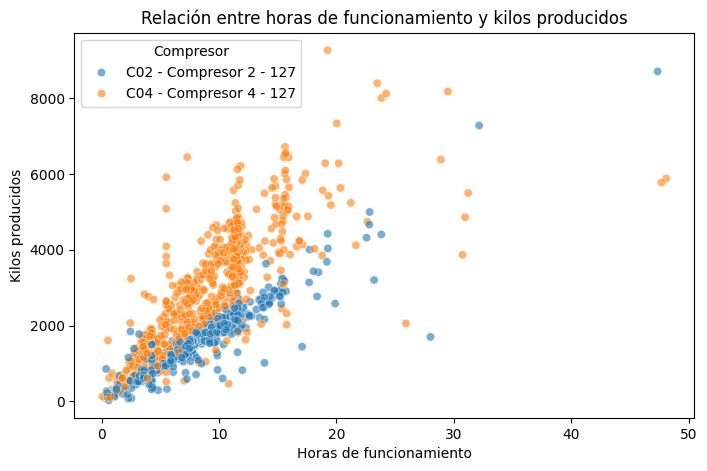

In [108]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=produccion_diaria_valida,
    x="Horas",
    y="Kilos_Producidos",
    hue="Compresor",
    alpha=0.6
)

plt.title("Relación entre horas de funcionamiento y kilos producidos")
plt.xlabel("Horas de funcionamiento")
plt.ylabel("Kilos producidos")
plt.show()

##### Interpretación

El gráfico muestra una relación positiva entre las horas de funcionamiento y los kilos producidos, consistente con la correlación obtenida de 0,78.

También se observa que el Compresor 4 tiende a alcanzar mayores niveles de producción para tiempos de funcionamiento similares, en concordancia con su mayor eficiencia productiva.

#### Comparación de la eficiencia productiva entre compresores

Se compara la eficiencia promedio de los compresores utilizando como indicador los kilos producidos por hora de funcionamiento.

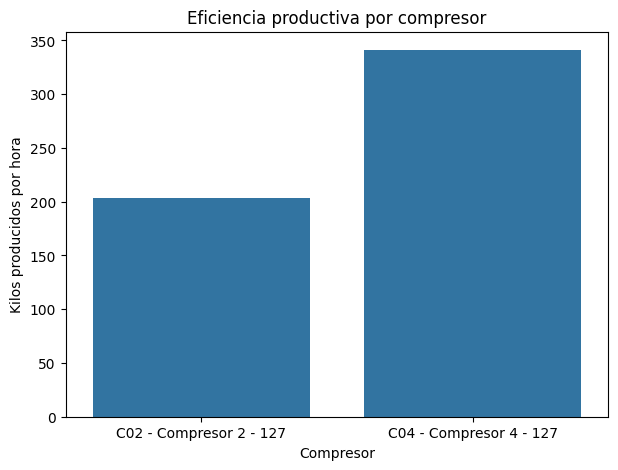

In [109]:
eficiencia_media = produccion_diaria_valida.groupby(
    "Compresor"
)["Kg_por_Hora"].mean().reset_index()

plt.figure(figsize=(7,5))

sns.barplot(
    data=eficiencia_media,
    x="Compresor",
    y="Kg_por_Hora"
)

plt.title("Eficiencia productiva por compresor")
plt.xlabel("Compresor")
plt.ylabel("Kilos producidos por hora")
plt.show()

##### Interpretación

El Compresor 4 presenta una mayor eficiencia productiva, con aproximadamente 341 kg por hora, frente a los 204 kg por hora del Compresor 2.

Esto representa una eficiencia productiva aproximadamente un 67 % mayor para el Compresor 4.

#### Evolución de la producción en el tiempo

Se analiza la evolución mensual de los kilos producidos por cada compresor, con el objetivo de identificar tendencias y variaciones en los niveles de producción a lo largo del período analizado.

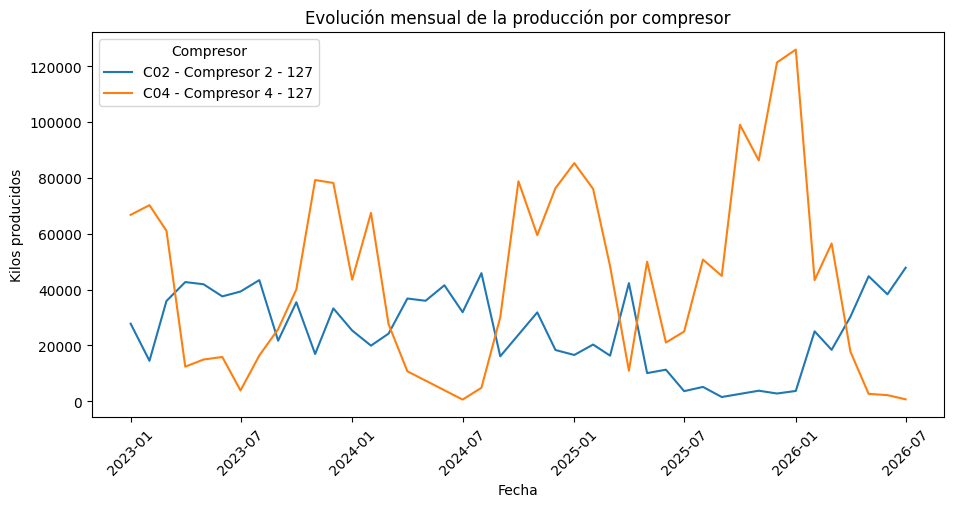

In [110]:
# Creamos una variable mensual
produccion_diaria_valida["Mes_Año"] = (
    produccion_diaria_valida["Fecha"].dt.to_period("M").dt.to_timestamp()
)

# Producción mensual por compresor
produccion_mensual = produccion_diaria_valida.groupby(
    ["Mes_Año", "Compresor"]
)["Kilos_Producidos"].sum().reset_index()

# Gráfico
plt.figure(figsize=(11,5))

sns.lineplot(
    data=produccion_mensual,
    x="Mes_Año",
    y="Kilos_Producidos",
    hue="Compresor"
)

plt.title("Evolución mensual de la producción por compresor")
plt.xlabel("Fecha")
plt.ylabel("Kilos producidos")
plt.xticks(rotation=45)
plt.show()

##### Interpretación

La producción presenta variaciones a lo largo del año, evidenciando un comportamiento estacional.

El Compresor 4 alcanza los mayores niveles de producción durante los períodos de mayor actividad, mientras que su utilización disminuye en los meses de menor producción. El Compresor 2 presenta niveles de producción más moderados y una participación mayor en períodos de menor actividad.

Este comportamiento es consistente con el uso del Compresor 4 como equipo de mayor capacidad durante los períodos de mayor demanda.

### Principales hallazgos e interpretación

El análisis permitió observar una marcada estacionalidad en la producción de hielo. Durante los períodos de mayor actividad aumenta considerablemente la producción y adquiere mayor participación el Compresor 4, mientras que en los períodos de menor actividad se utiliza en mayor medida el Compresor 2.

Esta diferencia responde también a una decisión operativa de la empresa. El Compresor 4 posee mayor capacidad productiva y puede trabajar con dos roliteras simultáneamente, por lo que su utilización resulta especialmente importante durante la temporada de mayor demanda.

El análisis de eficiencia mostró esta diferencia: el Compresor 4 alcanzó una producción promedio aproximada de 341 kg por hora, frente a 204 kg por hora del Compresor 2.

Sin embargo, la producción no depende únicamente de la capacidad de los equipos. Existen factores operativos que pueden generar variaciones importantes, como roturas de los compresores, reemplazo temporal del Compresor 4 por el Compresor 2 y disponibilidad de personal para realizar turnos nocturnos. Por esta razón, algunas jornadas pueden extenderse hasta 24 horas mientras que otras presentan períodos de producción más reducidos.

También se detectaron valores atípicos e inconsistencias en los registros. Algunos corresponden a errores de carga manual, mientras que otros pueden estar asociados a situaciones reales de la operación. Por este motivo, los valores atípicos fueron analizados considerando tanto criterios estadísticos como el conocimiento del proceso productivo.

En conjunto, los resultados muestran que la eficiencia de la producción debe analizarse considerando no solo los kilos producidos y las horas de funcionamiento, sino también la estacionalidad, la disponibilidad de los equipos y las condiciones operativas de la planta.

In [113]:
# Exportamos el dataset limpio para utilizar en Power BI
df.to_csv(
    "/content/drive/MyDrive/proyecto final Análisis de datos - UTNBA/produccion_hielo_limpio_ARG.csv",
    index=False,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print("Archivo generado correctamente para Power BI")

Archivo generado correctamente para Power BI
